In [1]:
import streamlit as st
from visualize_graph import plot_knowledge_graph

In [1]:
# ============================================================================
# SETUP: Import LLM Helper Functions
# ============================================================================
# We use helper functions to create LLM instances with proper configuration
# These functions handle API key loading and model configuration

import os
import sys

# Add parent directory to path for importing helpers
sys.path.append(os.path.abspath(".."))

# Import our LLM factory functions
# - get_groq_llm(): Creates a Groq-hosted LLM (fast inference)
# - get_openai_llm(): Creates an OpenAI GPT model
from helpers.utils import get_groq_llm, get_openai_llm,get_databricks_llm

print("LLM helpers imported successfully!")

# ============================================================================
# CREATE THE LLM AND CHATBOT GRAPH
# ============================================================================

# -----------------------------------------------------------------------------
# Step 1: Initialize the LLM
# We use Groq for fast inference, but you can swap to OpenAI
# -----------------------------------------------------------------------------
llm = get_databricks_llm("databricks-gemini-2-5-pro")  # Fast, open-source models hosted by Groq
# Alternative: llm = get_openai_llm()  # OpenAI's GPT models

if hasattr(llm, 'model_name'):
    print(f"LLM initialized: {llm.model_name}")
elif hasattr(llm, 'model'):
    print(f"LLM initialized: {llm.model} (Databricks)")
else:
    print("LLM initialized: Groq LLM")

/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/RAG_Demystified/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM helpers imported successfully!
LLM initialized: databricks-gemini-2-5-pro (Databricks)


In [2]:
def convert_to_chunks(file_path, max_words_per_chunk):
  chunks = []
  current_chunk = []
  current_word_count = 0
    
  with open(file_path, "r") as file:
    for line in file:
      words = line.split()
      current_word_count += len(words)
      if current_word_count < max_words_per_chunk:
        current_chunk.append(line.strip())
      else:
        chunks.append(' '.join(current_chunk))
        current_chunk = []
        current_word_count = 0
        current_word_count += len(words)
        current_chunk.append(line.strip())
    
    # Add any remaining text in the last chunk
    if current_chunk:
      chunks.append(' '.join(current_chunk))
    print("\nChunks created.\n")
    return chunks

In [13]:
def extract_entities_relationships(text):
    messages = [
    {"role": "system", "content": """"
    You are a helper tool for a knowedge graph builder application. Your task is to extract entities and relationships from the text provided by the user. 
    Format the output in such a way that it can be directly parsed into Python lists. 
    The format should include:
    
    1. A list of **Entities** in Python list format.
    2. A list of **Relationships**, where each relationship is represented as a tuple in the format: (Entity 1, "Relationship", Entity 2).
    
    Here is the format to follow:
    
    Entities: ["Entity 1", "Entity 2", ..., "Entity N"]
    
    Relationships: [("Entity 1", "Relationship", "Entity 2"), ..., ("Entity X", "Relationship", "Entity Y")]
    
    Example Input:
    Extract entities and relationships from the following text:
    "Michael Jackson, born in Gary, Indiana, was a famous singer known as the King of Pop. He passed away in Los Angeles in 2009."
    
    Expected Output:
    
    Entities: ["Michael Jackson", "Gary, Indiana", "Los Angeles", "singer", "King of Pop", "2009"]
    
    Relationships: [
      ("Michael Jackson", "born in", "Gary, Indiana"), 
      ("Michael Jackson", "profession", "singer"), 
      ("Michael Jackson", "referred to as", "King of Pop"), 
      ("Michael Jackson", "passed away in", "Los Angeles"), 
      ("Michael Jackson", "date of death", "2009")
    ]
    """},
    {"role": "user", "content": f"Extract entities and relationship tuples from the following text:\n\n{text}\n\n"}
    ]
  
    # response = client.chat.completions.create(
    #     model="gpt-4",
    #     messages=messages,
    # )
    response = llm.invoke(messages)
    print(response)
    response_content = response.content
    return response_content

In [14]:
import ast
def parse_llm_response_content(content):
    """
    Parse the LLM output to extract entities and relationships.
    """
    entity_section = content.split("Entities:")[1].split("Relationships:")[0].strip()
    relationship_section = content.split("Relationships:")[1].strip()

    entities = ast.literal_eval(entity_section)
    relationships = ast.literal_eval(relationship_section)
    
    return entities, relationships

In [15]:
def get_entities_relationships(file_path, wordsPerChunk=2665):
    """
    Chunk the input text, process each chunk, and combine results.
    """
    chunks = convert_to_chunks(file_path, wordsPerChunk)
    all_entities = []
    all_relationships = []
    i=1
    print("Number of chunks: ", len(chunks))
    for chunk in chunks:
        # Extract entities and relationships for each chunk
        content = extract_entities_relationships(chunk)
        print("Entities and realtionships have been extracted successfully for chunk ", i, ".\n")
        entities, relationships = parse_llm_response_content(content)
        print("Entities and realtionships have been parsed successfully for chunk ", i, ".\n")
        i=i+1
        # Aggregate entities and relationships
        all_entities.extend(entities)
        all_relationships.extend(relationships)
    
    # Remove duplicates from entities
    all_entities = list(set(all_entities))
    print("All entities and realtionships have been extracted successfully.")
    return all_entities, all_relationships

In [17]:
text_file_path = "./raw_text.txt"
wordsPerChunk=2665

entities, relationships = get_entities_relationships(text_file_path, wordsPerChunk)
plot_knowledge_graph(entities, relationships)


Chunks created.

Number of chunks:  3
content='Entities: ["Abraham Lincoln", "sixteenth President of the United States", "National Banking Act of 1863", "18 months", "1832", "The Legal Tender Act of 1862", "the United States Note", "first paper currency in United States history", "Grace Bedell", "Gettysburg address", "America", "1776", "John C. Breckinridge", "1860 Election", "Alton & Sangamon Railroad", "Southeast Hardin County, Kentucky", "March 4, 1861", "John Wilkes Booth", "General McClellan", "Battle of Antietam", "Emancipation Proclamation", "slaves", "the rebellion", "scholars", "top three presidents", "1816", "seven", "1846", "23 years", "William \\"Duff\\" Armstrong", "Lincoln\'s Wife\'s Family", "slavery", "Amedeo Avogadro", "theory of molarity and molecular weight", "ecclesiastical law", "20", "memoria", "1821", "professor", "1820", "Italian savant", "Turin", "August 9th 1776", "noble ancient family", "Piedmont, Italy", "King Victor Emmanuel III", "Avogadro\'s number", "ch

2026-01-26 18:53:43.236 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:53:43.867 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:53:43.887 
  command:

    streamlit run /Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/RAG_Demystified/.venv/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-01-26 18:53:43.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-01-26 18:57:35.809 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:57:36.415 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:57:36.472 
  command:

    streamlit run /Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/RAG_Demystified/.venv/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-01-26 18:57:36.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

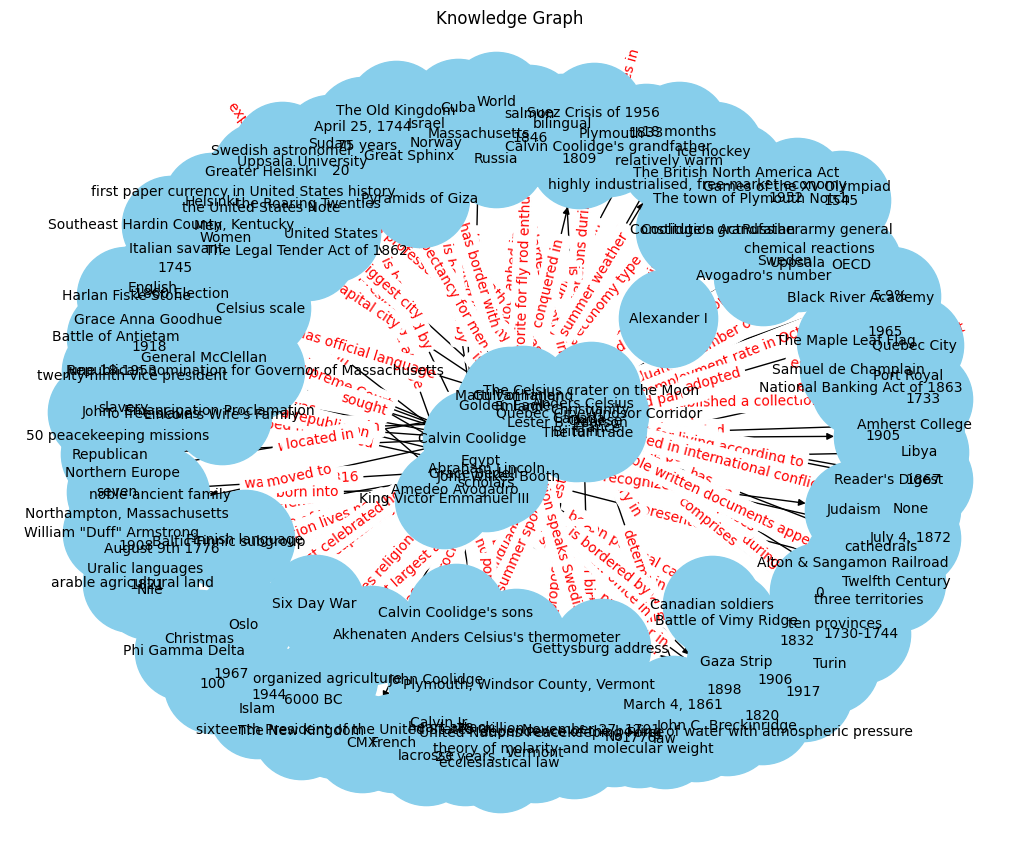

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import streamlit as st

G = nx.DiGraph()
    
# Add relationships as edges to the graph
for entity1, relationship, entity2 in relationships:
    G.add_edge(entity1, entity2, label=relationship)

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 8))

# Draw the graph with labels
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=5000, edge_color='black', font_size=10)

# Add edge labels
edge_labels = {(entity1, entity2): relationship for entity1, relationship, entity2 in relationships}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Knowledge Graph")
st.pyplot(plt)

In [3]:
# Streamlit app
st.title("Knowledge Graph Generator from Raw Text")

# Read raw text from an existing file in the same directory
st.write("Reading raw_text file...")
text_file_path = "./raw_text.txt"
wordsPerChunk=2665

# Extract entities and relationships from the raw text
# with st.spinner("Extracting entities and relationships..."):
#     entities, relationships = get_entities_relationships(text_file_path, wordsPerChunk)

# Display the extracted entities and relationships
st.write("### Extracted Entities")
st.write(entities)

st.write("### Extracted Relationship Tuples")
st.write(relationships)

# Display the knowledge graph
st.write("### Knowledge Graph")
plot_knowledge_graph(entities, relationships)

2026-01-26 18:59:12.396 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:59:12.456 
  command:

    streamlit run /Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/RAG_Demystified/.venv/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-01-26 18:59:12.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:59:12.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:59:12.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:59:12.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-26 18:59:12.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when 